In [2]:
import numpy as np
import dpluspy
import pickle

import matplotlib.pyplot as plt

In [3]:
fname = f"data/stats/stats_1e-4M_exon_buffer.pkl"
stats = dpluspy.inference.load_stats(fname, return_dict=True)
print(stats["bins"], len(stats["bins"]) - 1)

[0.00000000e+00 1.00000000e-07 1.77827941e-07 3.16227766e-07
 5.62341325e-07 1.00000000e-06 1.77827941e-06 3.16227766e-06
 5.62341325e-06 1.00000000e-05 1.77827941e-05 3.16227766e-05
 5.62341325e-05 1.00000000e-04 1.77827941e-04 3.16227766e-04
 5.62341325e-04 1.00000000e-03 1.77827941e-03 3.16227766e-03
 5.62341325e-03 1.00000000e-02 1.77827941e-02 3.16227766e-02
 5.62341325e-02 1.00000000e-01 1.77827941e-01 3.16227766e-01
 4.99999000e-01] 28


In [4]:
stats_subset = dpluspy.bootstrapping.subset_stats(
    stats, min_r=1e-7, max_r=1e-2, return_dict=True)
print(stats_subset["bins"], len(stats_subset["bins"]) - 1)
print(len(stats_subset["means"]), len(stats_subset["varcovs"]))
with open("data/stats/sub_1e-4M_buffer.pkl", "wb") as fout:
    pickle.dump(stats_subset, fout)

[1.00000000e-07 1.77827941e-07 3.16227766e-07 5.62341325e-07
 1.00000000e-06 1.77827941e-06 3.16227766e-06 5.62341325e-06
 1.00000000e-05 1.77827941e-05 3.16227766e-05 5.62341325e-05
 1.00000000e-04 1.77827941e-04 3.16227766e-04 5.62341325e-04
 1.00000000e-03 1.77827941e-03 3.16227766e-03 5.62341325e-03
 1.00000000e-02] 20
21 21


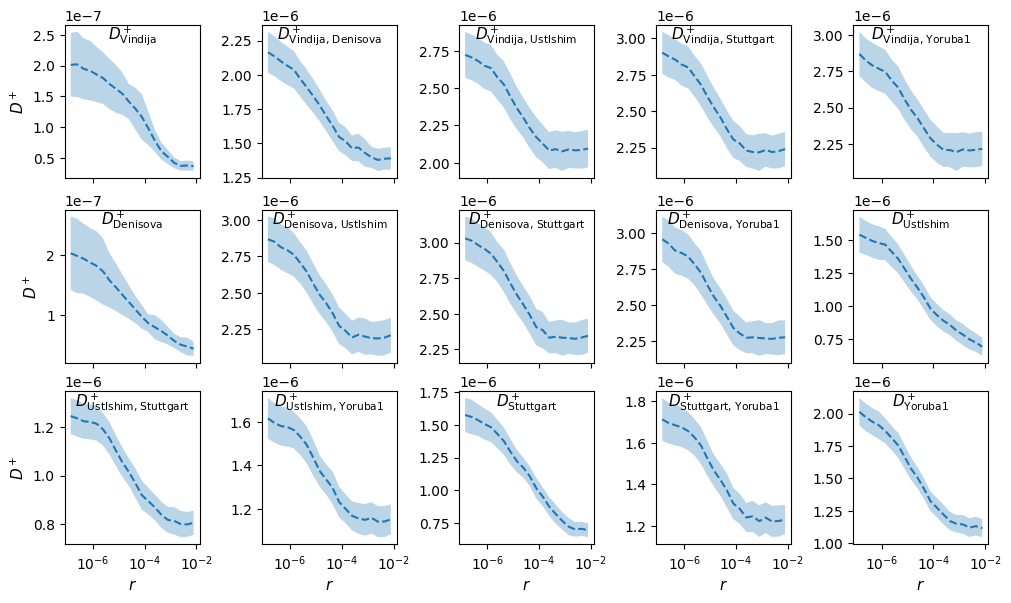

In [5]:
pops_to_plot = ["Vindija", "Denisova", "UstIshim", "Stuttgart", "Yoruba1"]
bins, means, varcovs = dpluspy.bootstrapping.subset_stats(
    stats_subset, to_pops=pops_to_plot, return_dict=False)
dpluspy.plotting.plot_d_plus_curves(means=means, varcovs=varcovs, bins=bins,
    pop_ids=pops_to_plot, out="figures/fig_1e-4M_buffer_trimmed.pdf")